In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.9 MB/s eta 0:00:00


In [ ]:
import optuna
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [ ]:
# set random seed for reproducibility
torch.manual_seed(42)

In [ ]:
# check for gpu
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device:{device}')

Using device:cuda


In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "fashion-mnist_train.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sanjeet41/fashionmnist-train",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/tmp/ipykernel_1232/3148370602.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'fashionmnist-train' dataset.


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,0,0,105,92,101,107,100,132,0,0,2,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,150,...,211,220,214,74,0,255,222,128,0,0,0,0,0,0,0,0,0,44,12,0,0,40,134,162,191,214,163,146,165,79,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,0,114,183,112,55,23,72,102,165,160,28,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,24,188,163,93,...,171,249,207,197,202,45,0,3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,22,21,25,69,52,45,74,39,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,0,0,0,46,0,21,68,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,25,187,189,...,230,237,229,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,68,116,112,136,147,144,121,102,63,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

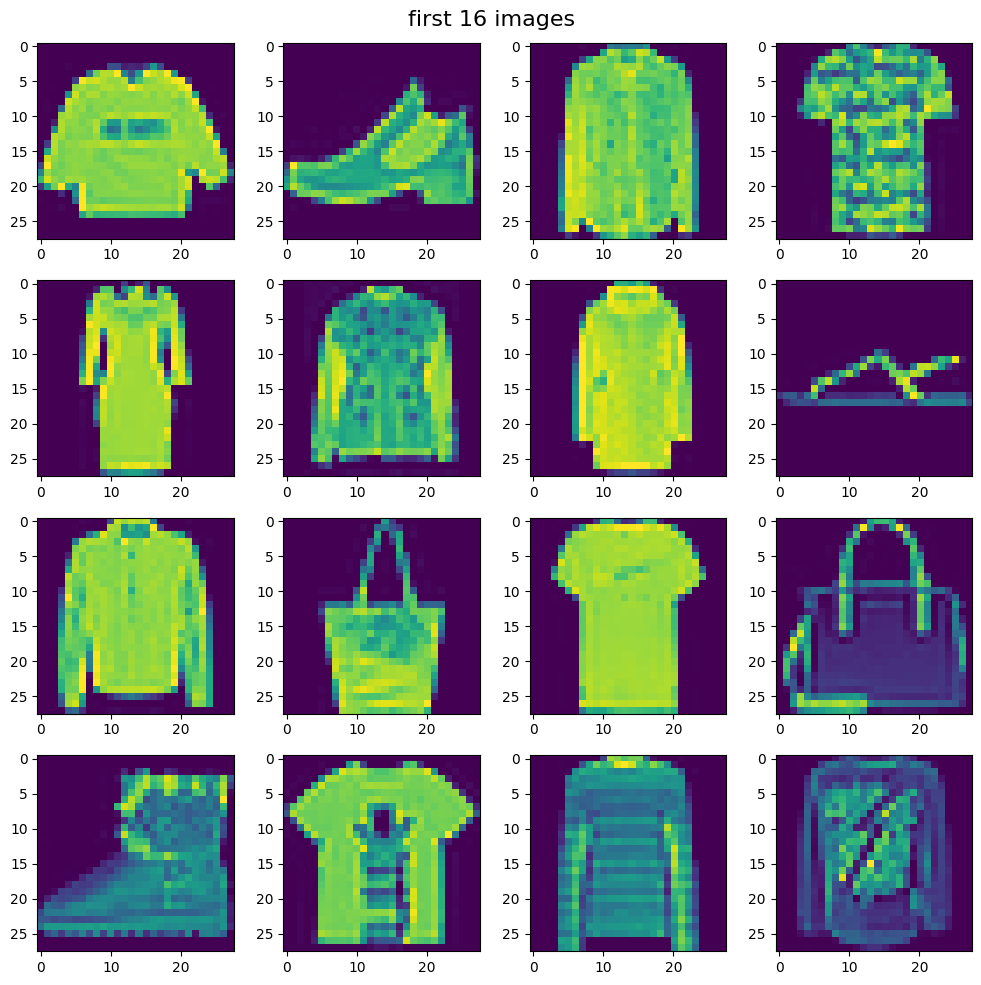

In [ ]:
# create a 4*4 grid of images
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle('first 16 images',fontsize=16)

# plot the first 16 images from the dataset
for i, ax,in enumerate(axes.flat):
    img=(df.iloc[i,1:].values.reshape(28,28))
    ax.imshow(img)

plt.tight_layout()
plt.show()

In [ ]:
# train test split
X=df.iloc[:,1:].values
y=df.iloc[:,0].values
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train=X_train/255.0
X_test=X_test/255.0

In [ ]:
from torchvision import transforms

# define data augmentations for the training dataset
train_transform=transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0,translate=(0.1,0.1)),
    transforms.ToTensor()
])

test_transform=transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor()
])

In [ ]:
class CustomDataset(Dataset):
  def __init__(self,features,labels,transforms=None):
    self.features=torch.tensor(features,dtype=torch.float32).reshape(-1,1,28,28)
    self.labels=torch.tensor(labels,dtype=torch.long)
    self.transforms=transforms

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    feature,label=self.features[index],self.labels[index]
    if self.transforms:
      feature=self.transforms(feature.squeeze(0).numpy())

    return feature,label


In [ ]:
# USE AUGMENTATIONS IN TRAINING DATA
train_dataset=CustomDataset(X_train,y_train,train_transform)
test_dataset=CustomDataset(X_test,y_test,test_transform)

In [ ]:
# Define the dynamic CNN model class

class DynamicNN(nn.Module):
  def __init__(self,num_conv_layers,num_filters,kerne_size,num_fc_layers,fc_layer_size,dropout_rate):
    super(DynamicNN,self).__init__()
    layers=[]

    in_channels=1

    # convolution layers

    for _ in range(num_conv_layers):
      layers.append(nn.Conv2d(in_channels,num_filters,kerne_size,padding='same'))
      layers.append(nn.ReLU())
      layers.append(nn.BatchNorm2d(num_filters))
      layers.append(nn.MaxPool2d(kernel_size=2,stride=2))
      in_channels=num_filters

    self.features=nn.Sequential(*layers)

    # Fully connected layers
    fc_layers=[nn.Flatten()]
    input_size=num_filters*(28//(2**num_conv_layers))**2

    for _ in range(num_fc_layers):
      fc_layers.append(nn.Linear(input_size,fc_layer_size))
      fc_layers.append(nn.ReLU())
      fc_layers.append(nn.Dropout(dropout_rate))
      input_size=fc_layer_size
    fc_layers.append(nn.Linear(input_size,10))

    self.classifier=nn.Sequential(*fc_layers)

  def forward(self,x):
    x=self.features(x)
    x=self.classifier(x)
    return x


In [ ]:
from torch.nn.modules import dropout
# Define the objective function for Optuna

def objective(trial):

  #  hyperparameters to tune
  num_conv_layers=trial.suggest_int('num_conv_layers',1,3)
  num_filters=trial.suggest_categorical('num_filters',[16,32,64,128,256])
  kernel_size=trial.suggest_categorical('kernel_size',[3,5])
  num_fc_layers=trial.suggest_int('num_fc_layers',1,3)
  fc_layer_size=trial.suggest_categorical('fc_layer_size',[64,128,256])
  dropout_rate=trial.suggest_uniform('dropout_rate',0.2,0.5)
  weight_decay=trial.suggest_loguniform('weight_decay',1e-5,1e-2)
  learning_rate=trial.suggest_loguniform('learning_rate',1e-4,1e-2)
  optimizer_name=trial.suggest_categorical('optimizer',['Adam','SGD','RMSprop'])
  batch_size=trial.suggest_categorical('batch_size',[32,64,128])
  num_epochs=trial.suggest_categorical('num_epochs',[10,30])


  # create the model
  model=DynamicNN(num_conv_layers,num_filters,kernel_size,num_fc_layers,fc_layer_size,dropout_rate).to(device)

  # data
  train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
  test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

  # optimizer
  if optimizer_name=='Adam':
    optimizer=optim.Adam(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
  elif optimizer_name=='SGD':
    optimizer=optim.SGD(model.parameters(),lr=learning_rate,momentum=0.9,weight_decay=weight_decay)
  else:
    optimizer=optim.RMSprop(model.parameters(),lr=learning_rate,weight_decay=weight_decay)

  # loss function
  criterion=nn.CrossEntropyLoss()

  # Training loop
  for epoch in range(num_epochs):
    model.train()

    for batch_features,batch_labels in train_loader:
      batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
      optimizer.zero_grad()
      outputs=model(batch_features)
      loss=criterion(outputs,batch_labels)
      loss.backward()
      optimizer.step()

  #  Validation Loop
  model.eval()
  correct=0
  total=0
  with torch.no_grad():
    for batch_features,batch_labels in test_loader:
      batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
      outputs=model(batch_features)
      _,predicted=torch.max(outputs,1)
      total += batch_labels.size(0)
      correct +=(predicted==batch_labels).sum().item()

  accuracy=100*correct/total
  return accuracy

In [ ]:
# Run the Optuna Study
pruner=optuna.pruners.MedianPruner()
study=optuna.create_study(direction='maximize',pruner=pruner)
study.optimize(objective,n_trials=100)

[I 2026-05-27 10:54:12,951] A new study created in memory with name: no-name-a0511652-15c9-42c1-8e22-76c049ee081f
/tmp/ipykernel_1232/3058541722.py:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate=trial.suggest_uniform('dropout_rate',0.2,0.5)
/tmp/ipykernel_1232/3058541722.py:13: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay=trial.suggest_loguniform('weight_decay',1e-5,1e-2)
/tmp/ipykernel_1232/3058541722.py:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate=trial.suggest_loguniform('learni

KeyboardInterrupt: 

In [ ]:
# Print the best hyperparameters and accuracy
print("Best hyperparameters:", study.best_params)
print("Best accuracy:", study.best_value)

Best hyperparameters: {'num_conv_layers': 2, 'num_filters': 128, 'kernel_size': 5, 'num_fc_layers': 3, 'fc_layer_size': 128, 'dropout_rate': 0.2278593697059545, 'weight_decay': 0.0019654409524241623, 'learning_rate': 0.001666205349360424, 'optimizer': 'SGD', 'batch_size': 32, 'num_epochs': 30}
Best accuracy: 90.44166666666666
